In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import geopandas as gpd
from shapely import wkt

creating a pandas dataframe

In [2]:
with open('..\\..\\data\\ecm1\\ecm1_fullmodel_novel.csv') as f:
    for _ in range(2):
        print(f.readline())

ï»¿Numb,Lon,Lat,Hcc,Sed,Hc,Type,DLy1,DLy2,DLy3,TLy1,TLy2,TLy3,RHO1,RHO2,RHO3,RHON

1,-179.5,89.5,6.4459,2.3303,8.7762,SOCE,4.4574,6.5846,8.7762,2.1271,2.1271,2.1916,2.654495089,2.736551637,2.895386984,3.30110365



In [3]:
dt = pd.read_csv('..\\..\\data\\ecm1\\ecm1_fullmodel_novel.csv', header=None, skiprows=1,
                names=['num', 'long', 'lat', 'hcc','sed','hc','type','z1','z2', 'z3','th1', 'th2', 'th3','rho1', 'rho2', 'rho3', 'rho_man'])
print(dt)

         num   long   lat      hcc     sed       hc  type       z1       z2  \
0          1 -179.5  89.5   6.4459  2.3303   8.7762  SOCE   4.4574   6.5846   
1          2 -178.5  89.5   6.3511  2.3344   8.6854  SOCE   4.4302   6.5261   
2          3 -177.5  89.5   6.2512  2.3398   8.5910  SOCE   4.4027   6.4656   
3          4 -176.5  89.5   6.1516  2.3463   8.4980  SOCE   4.3764   6.4064   
4          5 -175.5  89.5   6.0578  2.3520   8.4098  SOCE   4.3510   6.3501   
...      ...    ...   ...      ...     ...      ...   ...      ...      ...   
64795  64796  175.5 -89.5  39.0010  0.0000  39.0010  PLAT  12.8703  25.7406   
64796  64797  176.5 -89.5  39.0014  0.0000  39.0014  PLAT  12.8705  25.7409   
64797  64798  177.5 -89.5  39.0018  0.0000  39.0018  PLAT  12.8706  25.7412   
64798  64799  178.5 -89.5  39.0023  0.0000  39.0023  PLAT  12.8708  25.7415   
64799  64800  179.5 -89.5  39.0029  0.0000  39.0029  PLAT  12.8709  25.7419   

            z3      th1      th2      th3      rho1

In [4]:
df = dt[dt['long'].between(-140, -110) & dt['lat'].between(40, 60)]

# df.to_csv('..\\created_data\\trimmed_Hcc_ECM1.csv', index=False)

dataframe is a list with one row per point

pivot rearranges the dataframe into a grid-like spreadsheet
- index: values are row labels
- columns: values are column labels
- values: these values fill the cells

> ### example!
>
> dataframe shape: (64800, 3) and type: <class 'pandas.DataFrame'>
>
> pivot grid shape: (4, 4) and type: <class 'pandas.DataFrame'>

In [ ]:
df_grid_hcc = df.pivot(index='lat', columns='long', values='hcc')

lat = df_grid_hcc.index.values; long = df_grid_hcc.columns.values; hcc = df_grid_hcc.values

# print(df_grid_hcc.shape, lat.shape, long.shape, hcc.shape)

df_grid_hc = df.pivot(index='lat', columns='long', values='hc')

lat_hc = df_grid_hc.index.values; long_hc = df_grid_hc.columns.values; hc = df_grid_hc.values

: 

In [ ]:
fig, (ax1, ax2, ax3)= plt.subplots(1, 3, figsize=(20, 8))

pcm_hcc = ax1.pcolormesh(long, lat, hcc, cmap='jet')
# fig.colorbar(pcm_hcc, label='Thickness [km]')
ax1.scatter(-114.03, 51.02, marker='*', color='black', s=200, label='Calgary')
ax1.scatter(-123.06, 49.15, marker='^', color='black', s=200, label='Vancouver')

ax1.set_title('Crystalline Crustal Thickness')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')


pcm_hc = ax2.pcolormesh(long_hc, lat_hc, hc, cmap='jet')
fig.colorbar(pcm_hc, label='Thickness [km]')
ax2.scatter(-114.03, 51.02, marker='*', color='black', s=200, label='Calgary')
ax2.scatter(-123.06, 49.15, marker='^', color='black', s=200, label='Vancouver')

ax2.set_title('Total Crustal Thickness')
ax2.set_xlabel('Longitude')
# ax2.set_ylabel('Latitude')

# RESIDUAL$$$

res = hc-hcc

pcm_res = ax3.pcolormesh(long, lat, res, cmap='Blues')
fig.colorbar(pcm_res, label='Thickness [km]')
ax3.scatter(-114.03, 51.02, marker='*', color='black', s=200, label='Calgary')
ax3.scatter(-123.06, 49.15, marker='^', color='black', s=200, label='Vancouver')
ax3.scatter(-128.50, 56.50, marker='x', color='red', s=100, label='Bowser Basin')


ax3.set_title('Residual Crustal Thickness: Total - Crystalline')
ax3.set_xlabel('Longitude')
# ax3.set_ylabel('Latitude')

plt.legend()

plt.savefig('..\\..\\figures\\ecm1\\hcc_hc_compare.png', dpi=400, bbox_inches='tight')
plt.show()


not much of a difference.. but for some areas it is!! if we assume that the sediment coverage is 'linear' and we inject carbon into what we think is the crust, it may not be deep enough to safely hold the carbon for it to become a carbonate. also, if we inject it, we might not know the sediment cover in the middle of the 1 degree grid, it could thin and then thicken out again. 

### comparing to calgary...

crs='EPSG:4326': long/lat in degrees

In [ ]:
calgary = pd.read_csv('..\\..\\data\\ecm1\\City_Boundary_20261005.csv')

print(calgary.columns.tolist())   # find the column holding the geometry text

calgary['geometry'] = calgary['MULTIPOLYGON'].apply(wkt.loads)

gdf = gpd.GeoDataFrame(calgary, geometry='geometry', crs='EPSG:4326')

['CITY', 'MULTIPOLYGON', 'CREATED_DT']


In [ ]:
d_cal = dt[dt['long'].between(-115.5, -113.5) & dt['lat'].between(50.5, 52.5)]

In [ ]:
d_cal_grid_hcc = d_cal.pivot(index='lat', columns='long', values='hcc')

lat_cal = d_cal_grid_hcc.index.values; long_cal = d_cal_grid_hcc.columns.values; hcc_cal = d_cal_grid_hcc.values

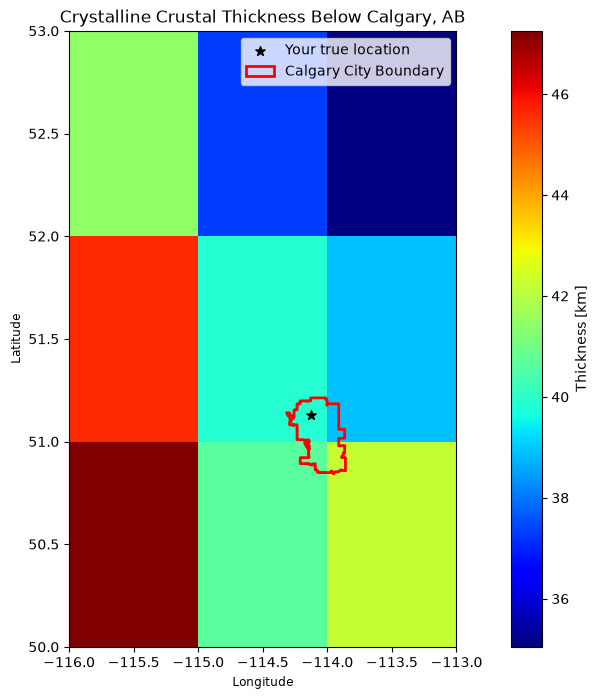

In [ ]:
fig, ax4 = plt.subplots(figsize=(14, 8))

pcm_cal = ax4.pcolormesh(long_cal, lat_cal, hcc_cal, cmap='jet')
fig.colorbar(pcm_cal, label='Thickness [km]')
ax4.scatter(-114.13, 51.13, marker='*', color='black', s=50, label='Your true location')
gdf.plot(ax=ax4, facecolor='none', edgecolor='red', linewidth=2, label='Calgary City Boundary')

ax4.set_title('Crystalline Crustal Thickness Below Calgary, AB')
ax4.set_xlabel('Longitude')
ax4.set_xticks(np.arange(long_cal.min()-0.5, long_cal.max()+1, 0.5))   # fixing ticks ugh
ax4.set_ylabel('Latitude')

ax4.legend()
plt.savefig('..\\..\\figures\\ecm1\\1.png', dpi=400, bbox_inches='tight')
plt.show()

idea is that if you live at the star, your location is essentially equivalent to anywhere in the entire purple box... you could even be from sundre! thats nearly an hour and a half drive.. think about all the scenary and little hills, roads, houses etc that can fix in that area that we are missing on the seafloor. 

another analogy, lets say you have a friend in calgary and want to send them a gift. the gift could go anywhere in the box! however, we want our gift to $at$ $least$ end up in the correct city. this is why we need a finer grid!

for carbon capture, if we don't have a finer grid, it is hard to narrow down where to send this gift. we do have some seismic coverage of the area, but some of the lines are outdated and most don't cover the entire area. 


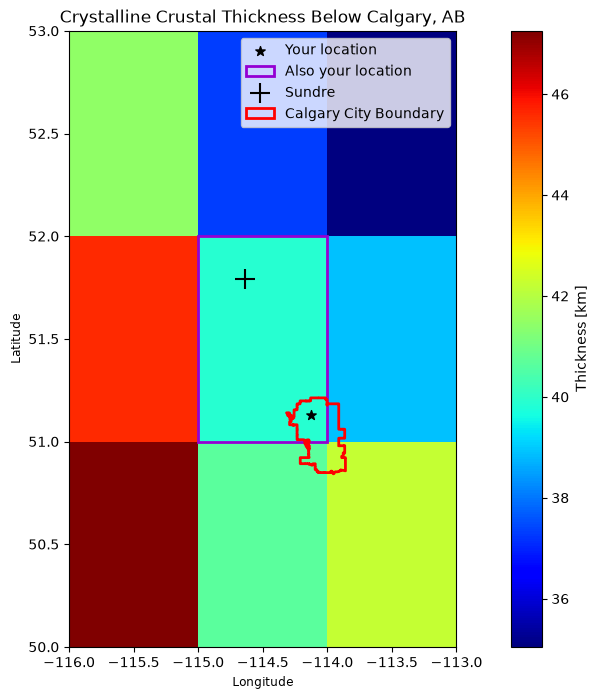

In [ ]:
fig, ax5 = plt.subplots(figsize=(14, 8))

pcm_cal = ax5.pcolormesh(long_cal, lat_cal, hcc_cal, cmap='jet')
fig.colorbar(pcm_cal, label='Thickness [km]')
ax5.scatter(-114.13, 51.13, marker='*', color='black', s=50, label='Your location')
ax5.add_patch(patches.Rectangle((-115, 51), 1, 1, linewidth=2, edgecolor='darkviolet', facecolor='none', label='Also your location'))
ax5.scatter(-114.64, 51.79, marker='+', color='black', s=200, label='Sundre')
gdf.plot(ax=ax5, facecolor='none', edgecolor='red', linewidth=2, label='Calgary City Boundary')


ax5.set_title('Crystalline Crustal Thickness Below Calgary, AB')
ax5.set_xlabel('Longitude')
ax5.set_xticks(np.arange(long_cal.min()-0.5, long_cal.max()+1, 0.5))   # fixing ticks ugh
ax5.set_ylabel('Latitude')

plt.legend()
plt.savefig('..\\..\\figures\\ecm1\\2.png', dpi=400, bbox_inches='tight')
plt.show()